In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(0)

In [87]:
cars = pd.read_csv("prepared_car_sales.csv")
np.random.seed(1)

In [88]:
cars.info()
print(cars.describe())
print(cars.shape)
cars.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14430 entries, 0 to 14429
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Index                    14430 non-null  int64  
 1   Price                    14430 non-null  int64  
 2   Currency                 14430 non-null  object 
 3   Condition                14430 non-null  object 
 4   Vehicle_brand            14430 non-null  object 
 5   Vehicle_model            14430 non-null  object 
 6   Vehicle_version          9887 non-null   object 
 7   Vehicle_generation       10212 non-null  object 
 8   Production_year          14430 non-null  int64  
 9   Mileage_km               14430 non-null  float64
 10  Power_HP                 14389 non-null  float64
 11  Displacement_cm3         14287 non-null  float64
 12  Fuel_type                14430 non-null  object 
 13  CO2_emissions            6536 non-null   float64
 14  Drive                 

Index(['Index', 'Price', 'Currency', 'Condition', 'Vehicle_brand',
       'Vehicle_model', 'Vehicle_version', 'Vehicle_generation',
       'Production_year', 'Mileage_km', 'Power_HP', 'Displacement_cm3',
       'Fuel_type', 'CO2_emissions', 'Drive', 'Transmission', 'Type',
       'Doors_number', 'Colour', 'Origin_country', 'First_owner',
       'First_registration_date', 'Offer_publication_date', 'Offer_location',
       'Features'],
      dtype='object')

array([[<Axes: title={'center': 'Index'}>,
        <Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Production_year'}>],
       [<Axes: title={'center': 'Mileage_km'}>,
        <Axes: title={'center': 'Power_HP'}>,
        <Axes: title={'center': 'Displacement_cm3'}>],
       [<Axes: title={'center': 'CO2_emissions'}>,
        <Axes: title={'center': 'Doors_number'}>, <Axes: >]], dtype=object)

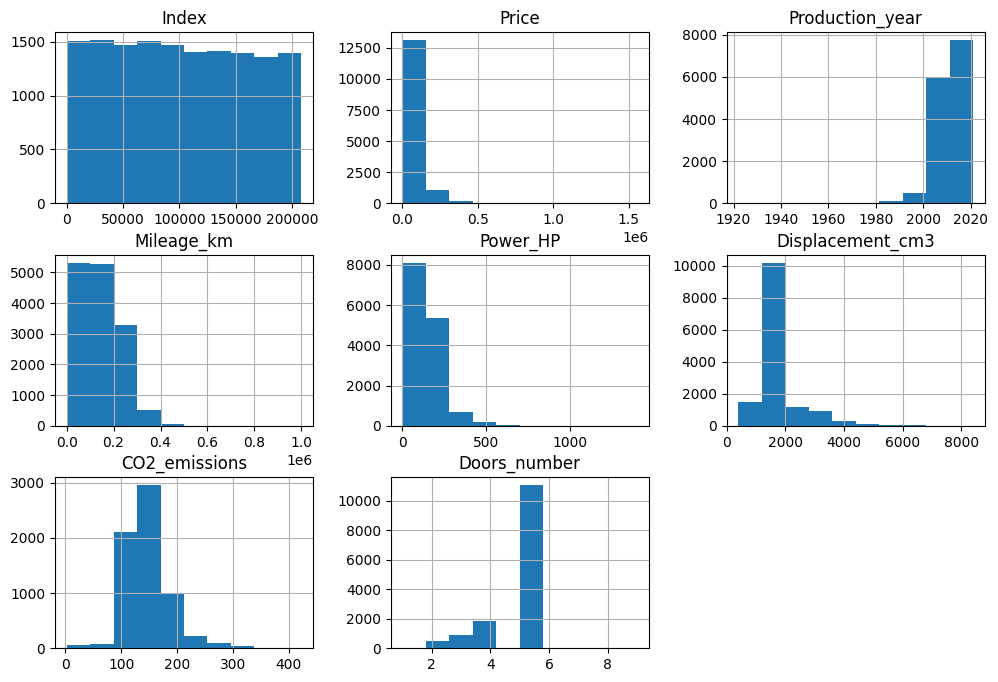

In [89]:
cars.hist(figsize=(12, 8))

In [167]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(cars, test_size=0.15 , random_state=0)
labels = train_set['Price']
test_labels = test_set['Price']

#train_set = train_set.drop(columns=['Price'])
#test_set = test_set.drop(columns=['Price'])

### Data analysis

In [91]:
tmp_df = train_set[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
for i, row in tmp_df.iterrows():
    if row['Currency'] == 'EUR':
        tmp_df.at[i, 'Price'] = row['Price'] * 4.26
tmp_df = tmp_df.drop(columns='Currency')
tmp_df['Condition'] = tmp_df['Condition'].map({'Used': 0, 'New': 1})
corr_mtx = tmp_df.corr()
corr_mtx['Price'].sort_values(ascending=False)

C:\Users\mikołaj\AppData\Local\Temp\ipykernel_6236\3113421748.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8051.4' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  tmp_df.at[i, 'Price'] = row['Price'] * 4.26


Price              1.000000
Power_HP           0.628924
Condition          0.444234
Production_year    0.410088
CO2_emissions      0.188188
Mileage_km        -0.505205
Name: Price, dtype: float64

In [92]:
dummies = pd.get_dummies(train_set['Vehicle_brand'], dummy_na=False) #, prefix='brand'
corrs = dummies.apply(lambda col: col.corr(cars['Price']))
corrs.sort_values(ascending=False).head(10)

Porsche          0.187021
Ferrari          0.157980
McLaren          0.153468
Bentley          0.139778
Lamborghini      0.133244
BMW              0.133079
Mercedes-Benz    0.125778
Land Rover       0.118499
Rolls-Royce      0.114679
Audi             0.075250
dtype: float64

In [93]:
# print(train_set['Type'].unique())
# print(train_set['Transmission'].unique())

dummies = pd.get_dummies(train_set['Type'], dummy_na=False) #, prefix='brand'
corrs = dummies.apply(lambda col: col.corr(cars['Price']))
print(corrs.sort_values(ascending=False), '\n')

dummies = pd.get_dummies(train_set['Transmission'], dummy_na=False) #, prefix='brand'
corrs = dummies.apply(lambda col: col.corr(cars['Price']))
print(corrs.sort_values(ascending=False))

SUV              0.288929
coupe            0.131827
sedan            0.063268
convertible      0.047107
small_cars      -0.077725
minivan         -0.087670
station_wagon   -0.088786
compact         -0.116980
city_cars       -0.156929
dtype: float64 

Automatic    0.472969
Manual      -0.471245
dtype: float64


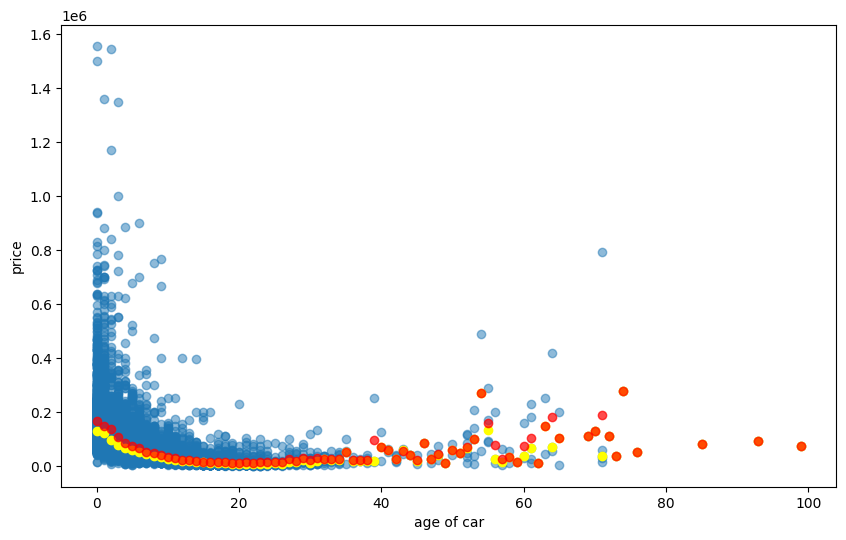

In [94]:
fig, axis = plt.subplots(figsize=(10, 6))
tmp_df = train_set[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
tmp_df['Years'] = 2021 - tmp_df['Production_year']
avg_prices = tmp_df.groupby('Years')['Price'].mean()
median_prices = tmp_df.groupby('Years')['Price'].median()
axis.scatter(tmp_df['Years'], tmp_df['Price'], alpha=0.5)
axis.scatter(median_prices.index, median_prices, c='yellow', alpha=1)
axis.scatter(avg_prices.index, avg_prices, c='red', alpha=0.7)
tmp = pd.concat([avg_prices, median_prices], axis=1)

axis.set_xlabel(xlabel='age of car')
axis.set_ylabel(ylabel='price')
plt.show()

C:\Users\mikołaj\AppData\Local\Temp\ipykernel_6236\2730224213.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
C:\Users\mikołaj\AppData\Local\Temp\ipykernel_6236\2730224213.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()


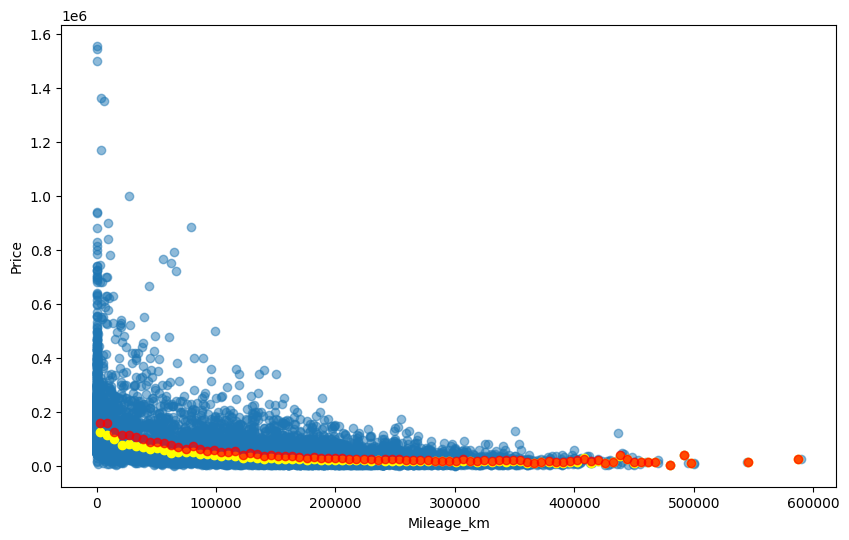

In [95]:
fig, axis = plt.subplots(figsize=(10, 6))
tmp_df = train_set[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
lin = np.linspace(start=0, stop=tmp_df['Mileage_km'].max(), num=100)
indexes = (lin[:-1] + lin[1:]) / 2

tmp_df['mileage_group'] = pd.cut(tmp_df['Mileage_km'], bins=lin)
avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()
# print(avg_prices)
# print(median_prices)
axis.scatter(tmp_df['Mileage_km'], tmp_df['Price'], alpha=0.5)
axis.scatter(indexes, median_prices['Price'], c='yellow', alpha=1)
axis.scatter(indexes, avg_prices['Price'], c='red', alpha=0.7)
# tmp = pd.concat([avg_prices, median_prices], axis=1)

axis.set_xlabel(xlabel='Mileage_km')
axis.set_ylabel(ylabel='Price')
plt.show()

C:\Users\mikołaj\AppData\Local\Temp\ipykernel_6236\3354255719.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
C:\Users\mikołaj\AppData\Local\Temp\ipykernel_6236\3354255719.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()


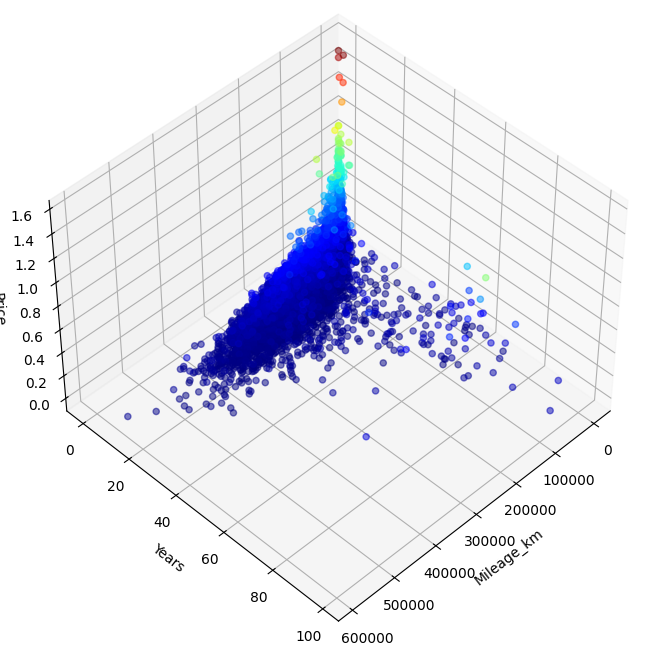

In [96]:
fig = plt.figure(figsize=(12, 8))
axis = plt.axes(projection='3d')

tmp_df = train_set[['Price', 'Production_year', 'Mileage_km', 'Condition', 'Power_HP', 'CO2_emissions', 'Currency']].copy()
tmp_df['Years'] = 2021 - tmp_df['Production_year']
lin = np.linspace(start=0, stop=tmp_df['Mileage_km'].max(), num=200)
indexes = (lin[:-1] + lin[1:]) / 2

tmp_df['mileage_group'] = pd.cut(tmp_df['Mileage_km'], bins=lin)
avg_prices = tmp_df.groupby('mileage_group')['Price'].mean().reset_index()
median_prices = tmp_df.groupby('mileage_group')['Price'].median().reset_index()

axis.scatter(tmp_df['Mileage_km'], tmp_df['Years'], tmp_df['Price'], alpha=0.5,
             c=tmp_df['Price'], cmap='jet') #viridis, jet
axis.view_init(azim=45, elev=45)

axis.set_xlabel(xlabel='Mileage_km')
axis.set_ylabel(ylabel='Years')
axis.set_zlabel(zlabel='Price')

plt.show()

### Pipeline

In [76]:
def currency_conversion(row, rules: dict):
    if row['Currency'] in rules:
        row['Price'] = row['Price'] * rules[row['Currency']]
    return row

from sklearn.base import BaseEstimator, TransformerMixin

class ExclusiveCars(BaseEstimator, TransformerMixin):
    def __init__(self, brand_col, ex_cars):
        self.brand_col = brand_col
        self.ex_cars = ex_cars
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = np.asarray(X).copy()
        X[:, self.brand_col] = np.isin(X[:, self.brand_col], list(self.ex_cars)).astype(int)
        return X



In [168]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_attributes = ['Years', 'Mileage_km', 'Power_HP', 'CO2_emissions']
cat_attributes = ['Condition', 'Transmission', 'Type', 'Vehicle_brand']

"""
Used     Automatic     SUV   
New      Manual        coupe
                       sedan        
                       convertible  
                       small_cars   
                       minivan      
                       station_wagon
                       compact      
                       city_cars    
"""

ex_cars = [
    "Porsche",
    "Ferrari",
    "McLaren",
    "Bentley",
    "Lamborghini",
    "BMW",
    "Mercedes-Benz",
    "Land Rover",
    "Rolls-Royce"
]

#Axis 0 will act on all the ROWS in each COLUMN
#Axis 1 will act on all the COLUMNS in each ROW
train_set.apply(lambda row: currency_conversion(row, {'EUR': 4.26}), axis=1)
train_set['Years'] = 2022 - train_set['Production_year']

######################TEST SETS###########################
test_set.apply(lambda row: currency_conversion(row, {'EUR': 4.26}), axis=1)
test_set['Years'] = 2022 - test_set['Production_year']


num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('exclusive-cars', ExclusiveCars(cat_attributes.index('Vehicle_brand'), ex_cars)),
    ('one-hot-encoder', OneHotEncoder()),
])

final_pipeline = ColumnTransformer(transformers= [
    ('nums', num_pipeline, num_attributes),
    ('cats', cat_pipeline, cat_attributes),
],
remainder='drop',
n_jobs=-1,
)

train_set = final_pipeline.fit_transform(train_set)
test_set = final_pipeline.fit_transform(test_set)

In [148]:
train_set[0]

array([ 0.1173435 ,  0.20204772, -0.45585357, -0.10160113,  0.        ,
        1.        ,  0.        ,  1.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
        0.        ,  0.        ,  1.        ,  0.        ])

### Models

In [154]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error as mape

def final_rmse(model, test_labels):
    final_mse = mean_squared_error(test_labels, model.predict(test_set))
    return np.sqrt(final_mse)

def evaluate(model, test_set, test_labels):
    #model.fit(test_set, test_labels)

    #predictions = model.predict(test_set)
    #errors = abs(predictions - test_labels)
    #mape = 100 * np.mean(errors / test_labels)
    #accuracy = 100 - mape
    
    print('Model Performance')
    #print('Average Error: {:0.4f} degrees.'.format(np.mean(errors)))
    print('Accuracy = {:0.2f}%.'.format(1-mape(test_labels, model.predict(test_set))))
    print('final_rmse: ', final_rmse(model,test_labels))

#### RandomForest

In [155]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

params = {'bootstrap': [True, False],
          'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
          'max_features': [2, 3, 4, 5, 6, None],
          'min_samples_leaf': [1, 2, 4],
          'min_samples_split': [2, 5, 10],
          'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]}
forest_reg = RandomForestRegressor()

random_search = RandomizedSearchCV(estimator=forest_reg, param_distributions=params,
                                   n_iter=10, cv=5, random_state=42, n_jobs=-1, verbose=3)

random_search.fit(train_set, labels)
print(random_search.best_params_)
print(random_search.best_estimator_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'n_estimators': 1400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10, 'bootstrap': True}
RandomForestRegressor(max_depth=10, max_features=None, min_samples_split=5,
                      n_estimators=1400)


In [156]:
evaluate(random_search.best_estimator_, test_set, test_labels)

Model Performance
Accuracy = 0.71%.
final_rmse:  30433.919052785233


In [157]:
from sklearn.compose import TransformedTargetRegressor

best_params = {'n_estimators': 1400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 10, 'bootstrap': True}

base = RandomForestRegressor(**best_params)
model = TransformedTargetRegressor(regressor=base, func=np.log1p, inverse_func=np.expm1)
model.fit(train_set, labels)
print()

In [158]:
evaluate(model, test_set, test_labels)

from sklearn.model_selection import cross_val_score
#scores = cross_val_score()

Model Performance
Accuracy = 0.75%.
final_rmse:  31696.392893376986


### LGBMRegressor

In [ ]:
from lightgbm import LGBMRegressor

lgbmreg_params = {
    'n_estimators': [300, 500, 800, 1200, 2000],
    'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 5, 7, 9, 12],
    'min_child_samples': [10, 20, 30, 50, 100],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.0, 0.1, 0.5, 1.0]
}

lgbmreg = LGBMRegressor(objective='regression')

lgbmreg_random_search = RandomizedSearchCV(estimator=lgbmreg, param_distributions=lgbmreg_params,
                                   n_iter=15, cv=5, random_state=42, n_jobs=-1, verbose=3)

lgbmreg_random_search.fit(train_set, labels)
print(lgbmreg_random_search.best_params_)
print(lgbmreg_random_search.best_estimator_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000958 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 807
[LightGBM] [Info] Number of data points in the train set: 12265, number of used features: 19
[LightGBM] [Info] Start training from score 64301.336078
{'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
LGBMRegressor(colsample_bytree=0.6, learning_rate=0.05, n_estimators=500,
              num_leaves=15, objective='regression', reg_alpha=0.1,
              reg_lambda=1.0, subsample=0.9)


In [163]:
evaluate(lgbmreg_random_search.best_estimator_, test_set, test_labels)

Model Performance
Accuracy = 0.72%.
final_rmse:  31758.162394431864


d:\matura\komis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\matura\komis\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### HistGradientBoostingRegressor

In [178]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgbreg_params = {
    "max_iter": [100, 200, 500, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [20, 50, 100, 200],
    "max_leaf_nodes": [31, 63, 127, None],
    "l2_regularization": [0.0, 0.1, 0.5, 1.0],
    "max_bins": [16, 32, 64, 128, 255],
    "categorical_features": [None],
}

hgbreg = HistGradientBoostingRegressor()

hgbreg_random_search = RandomizedSearchCV(estimator=hgbreg, param_distributions=hgbreg_params,
                                   n_iter=15, cv=5, random_state=42, n_jobs=-1, verbose=3)

hgbreg_random_search.fit(train_set, labels)
print(hgbreg_random_search.best_params_)
print(hgbreg_random_search.best_estimator_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
{'min_samples_leaf': 50, 'max_leaf_nodes': 127, 'max_iter': 1000, 'max_depth': 5, 'max_bins': 255, 'learning_rate': 0.01, 'l2_regularization': 0.1, 'categorical_features': None}
HistGradientBoostingRegressor(categorical_features=None, l2_regularization=0.1,
                              learning_rate=0.01, max_depth=5, max_iter=1000,
                              max_leaf_nodes=127, min_samples_leaf=50)


In [180]:
evaluate(hgbreg_random_search.best_estimator_, test_set, test_labels)

Model Performance
Accuracy = 0.69%.
final_rmse:  31004.231868403378


#### SVM

In [181]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV

params = {
    'C': [10, 100, 1000, 2000, 2500, 3000, 3500, 4000],
    'epsilon': [0.5, 0.7, 1.0, 1.5, 2, 2.5, 3, 3.5],
    'gamma': ['scale', 'auto', 0.005, 0.01, 0.05, 0.1, 0.2, 0.5],
    'kernel': ['rbf']
}
svm = SVR()

svm_random_search = RandomizedSearchCV(estimator=svm, param_distributions=params,
                                 n_iter=10, cv=5, random_state=42, n_jobs=-1, verbose=3)

svm_random_search.fit(train_set, labels)
print(svm_random_search.best_params_)
print(svm_random_search.best_estimator_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'kernel': 'rbf', 'gamma': 'auto', 'epsilon': 3, 'C': 4000}
SVR(C=4000, epsilon=3, gamma='auto')


In [183]:
evaluate(svm_random_search.best_estimator_, test_set, test_labels)

Model Performance
Accuracy = 0.73%.
final_rmse:  43223.479542668196


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

params = {
    'C': [4000, 4500, 5000],
    'epsilon': [3, 3.5, 4, 4.5],
    'gamma': ['auto'],
    'kernel': ['rbf']
}
svm = SVR()

grid_search = GridSearchCV(estimator=svm, param_grid=params,
                            cv=3, n_jobs=-1, verbose=3,
                            return_train_score=True)

grid_search.fit(train_set, labels)
print(grid_search.best_params_)
print(grid_search.best_estimator_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'C': 5000, 'epsilon': 3, 'gamma': 'auto', 'kernel': 'rbf'}
SVR(C=5000, epsilon=3, gamma='auto')


In [ ]:
evaluate(grid_search.best_estimator_, test_set, test_labels)

Model Performance
Average Error: 17714.0651 degrees.
Accuracy = 70.86%.
final_rmse:  50071.52312606249
